# Modelos de Regresion

La regresión es una herramienta que permite estimar la media condicional a una o más variables de una variable dependiente (Y) dado un conjunto de otras variables llamadas regresoras, variables condicionales o covariables (X).

$$E(Y|\mathbf{X}) = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_k X_k + \varepsilon$$

* $E(Y|\mathbf{X})$ es el valor esperado de $Y$ dado el conjunto de covariables $\mathbf{X}$
* $\beta_k$ estima el cambio promedio esperado en $Y$ ante cambios en $X_k$
* $\beta_0$ es el intercepto de la regresión
* $\varepsilon$ errores de estimación

# Regresion lineal en Series de Tiempo

$$y_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \cdots + \beta_k x_{k,t} + \epsilon_t$$

Aunque la fórmula sea la misma, los supuestos cambian drásticamente. En una regresión normal, asumimos que las observaciones son independientes. En series de tiempo, esto casi nunca es cierto debido a:

- Autocorrelación: Lo que pasó ayer suele influir en lo que pasa hoy. Si hay autocorrelación en los errores ($\epsilon_t$), los resultados de tu regresión lineal simple pueden ser engañosos.
- Estacionalidad: Patrones que se repiten (ej. las ventas suben siempre en diciembre).
- No estacionariedad: Si la media o la varianza de la serie cambian con el tiempo, la regresión lineal puede dar "correlaciones espurias" (parece que hay relación, pero es solo coincidencia temporal)

**Nota importante:** En series de tiempo, el orden de los datos no se puede alterar. Si barajas las filas (como harías en otros modelos de Machine Learning), pierdes toda la información de la estructura temporal

/tmp/ipykernel_24205/3772101029.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


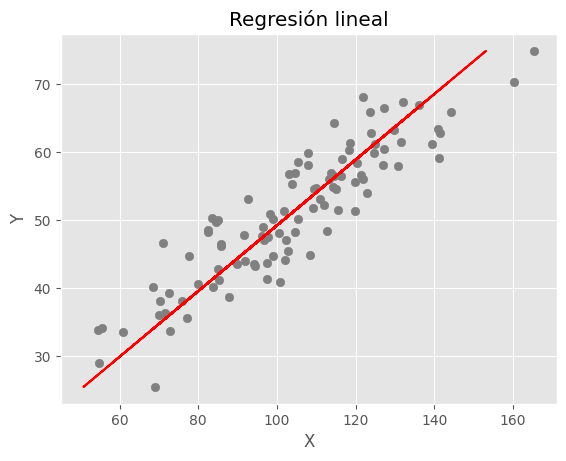

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

x = np.random.normal(50, 10, 100)
y = np.random.normal(2, 10, 100) + 2 * x + np.random.normal(0, 1, 100)
X = sm.add_constant(x)
lm = sm.OLS(y, X).fit()
y_hat = lm.predict()

plt.style.use('ggplot')
fig, ax = plt.subplots()
ax.scatter(y, x, color = "gray")
ax.plot(y_hat, x, color = "red")
plt.title('Regresión lineal')
plt.xlabel('X')
plt.ylabel('Y')
fig.show()

## Estimador de Minimos Cuadrados Ordinarios (MCO)

El estimador MCO permite buscar los coeficientes βk de una regresión tal que minimiza la suma de los errores (el valor más pequeño) de la regresión.

### Ecuaciones del Modelo de Regresión

1. **Definición del error (residuo):**
$$\epsilon_t = y_t - \hat{y}_t$$

2. **Modelo de regresión múltiple:**
$$\hat{y}_t = \beta_0 + \beta_1 x_{1,t} + \beta_2 x_{2,t} + \cdots + \beta_k x_{k,t} + \epsilon_t$$

3. **Suma de los cuadrados de los residuos (Mínimos Cuadrados Ordinarios):**
$$\sum_{t=1}^{T} \epsilon_t^2 = \sum_{t=1}^{T} (y_t - \beta_0 - \beta_1 x_{1,t} - \beta_2 x_{2,t} - \cdots - \beta_k x_{k,t})^2$$

4. **Supuesto de normalidad de los errores:**
* Supuesto $\hat{\epsilon}_t \sim N(0, \sigma^2)$

## Comprobación Práctica de Mínimos Cuadrados Ordinarios (MCO)

Para entender cómo funciona la regresión en series de tiempo, utilizaremos un conjunto de datos simulado muy corto ($T=3$).

### 1. Datos de la Serie de Tiempo
| Tiempo ($t$) | Variable Independiente ($x_t$) | Variable Dependiente ($y_t$) |
| :--- | :--- | :--- |
| 1 | 1 | 3 |
| 2 | 2 | 4 |
| 3 | 3 | 6 |

**Coeficientes estimados (Asumidos):**
* $\hat{\beta}_0 = 1.33$
* $\hat{\beta}_1 = 1.5$

---

### 2. Proceso de Cálculo de Residuos

Utilizamos la fórmula de la recta estimada: $\hat{y}_t = \hat{\beta}_0 + \hat{\beta}_1 x_t$ y luego calculamos el error $\epsilon_t = y_t - \hat{y}_t$.

#### A. Valores Estimados ($\hat{y}_t$)
* $\hat{y}_1 = 1.33 + 1.5(1) = 2.83$
* $\hat{y}_2 = 1.33 + 1.5(2) = 4.33$
* $\hat{y}_3 = 1.33 + 1.5(3) = 5.83$

#### B. Cálculo de los Errores al Cuadrado ($\epsilon_t^2$)
Aplicamos la fórmula de la sumatoria que minimiza el modelo:

$$
\sum_{t=1}^{T} \epsilon_t^2 = \sum_{t=1}^{T} (y_t - \hat{y}_t)^2
$$

**Desarrollo paso a paso:**

$$
\begin{aligned}
\epsilon_1^2 &= (3 - 2.83)^2 = (0.17)^2 = 0.0289 \\
\epsilon_2^2 &= (4 - 4.33)^2 = (-0.33)^2 = 0.1089 \\
\epsilon_3^2 &= (6 - 5.83)^2 = (0.17)^2 = 0.0289 \\
\hline
\sum \epsilon_t^2 &= \mathbf{0.1667}
\end{aligned}
$$

---

### 3. Conclusión del Supuesto $\hat{\epsilon}_t \sim N(0, \sigma^2)$
En este ejercicio manual, observamos que:
1. La suma de los errores simples $\sum \epsilon_t$ es aproximadamente $0$ ($0.17 - 0.33 + 0.17 = 0.01$, la diferencia es por redondeo de decimales).
2. El valor de $0.1667$ representa la **variabilidad no explicada** por el modelo. Cuanto menor sea este número, mejor ajusta nuestra línea de regresión a los datos históricos.

---

# Demostración Matemática de los Estimadores MCO

El objetivo es minimizar la Función de Pérdida $L$, que es la Suma de los Cuadrados de los Residuos (SCR):

$$L(\beta_0, \beta_1) = \sum_{t=1}^{T} \epsilon_t^2 = \sum_{t=1}^{T} (y_t - \beta_0 - \beta_1 x_t)^2$$

### 1. Condiciones de Primer Orden (Derivadas Parciales)
Para hallar el mínimo, derivamos $L$ respecto a cada parámetro e igualamos a cero:

**Respecto a $\beta_0$:**
$$\frac{\partial L}{\partial \beta_0} = -2 \sum_{t=1}^{T} (y_t - \beta_0 - \beta_1 x_t) = 0$$

**Respecto a $\beta_1$:**
$$\frac{\partial L}{\partial \beta_1} = -2 \sum_{t=1}^{T} x_t (y_t - \beta_0 - \beta_1 x_t) = 0$$

---

### 2. Obtención de los Estimadores

#### A. Estimador del Intercepto ($\hat{\beta_0}$)
De la primera ecuación, dividimos por $-2$ y distribuimos la sumatoria:
$$\sum y_t - \sum \beta_0 - \beta_1 \sum x_t = 0$$
$$\sum y_t - T\beta_0 - \beta_1 \sum x_t = 0$$

Si dividimos todo entre $T$ (el número de periodos), obtenemos las medias ($\bar{y}$ y $\bar{x}$):
$$\bar{y} - \hat{\beta_0} - \hat{\beta_1} \bar{x} = 0 \implies \mathbf{\hat{\beta_0} = \bar{y} - \hat{\beta_1} \bar{x}}$$

#### B. Estimador de la Pendiente ($\hat{\beta_1}$)
Sustituyendo $\hat{\beta_0}$ en la segunda ecuación de las derivadas y despejando $\beta_1$, llegamos a la fórmula clásica:

$$\mathbf{\hat{\beta_1} = \frac{\sum_{t=1}^{T} (x_t - \bar{x})(y_t - \bar{y})}{\sum_{t=1}^{T} (x_t - \bar{x})^2}}$$

O en términos de covarianza y varianza:
$$\hat{\beta_1} = \frac{Cov(x, y)}{Var(x)}$$

### 2.2. El "Desmenuzado" de la Pendiente ($\hat{\beta}_1$)

Muchos textos saltan de la derivada a la fracción final. Aquí vemos paso a paso cómo llegamos a la relación entre covarianzas y varianzas.

#### Paso 1: Partimos de la segunda condición de primer orden
Después de derivar la Suma de Cuadrados de los Residuos (SCR) respecto a $\beta_1$ e igualar a cero, tenemos:
$$\sum_{t=1}^{T} x_t (y_t - \hat{\beta}_0 - \hat{\beta}_1 x_t) = 0$$

#### Paso 2: Sustitución del Intercepto ($\hat{\beta}_0$)
Sabemos por la primera derivada que $\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$. Al sustituirlo en la ecuación de arriba:
$$\sum x_t [y_t - (\bar{y} - \hat{\beta}_1 \bar{x}) - \hat{\beta}_1 x_t] = 0$$

Agrupamos los términos que tienen $\hat{\beta}_1$:
$$\sum x_t [(y_t - \bar{y}) - \hat{\beta}_1 (x_t - \bar{x})] = 0$$

#### Paso 3: Distribución de la sumatoria
Separamos la ecuación en dos sumatorias:
$$\sum x_t (y_t - \bar{y}) = \hat{\beta}_1 \sum x_t (x_t - \bar{x})$$

#### Paso 4: El truco de las desviaciones medias
Aquí aplicamos una propiedad fundamental de las sumatorias: $\sum x_t (y_t - \bar{y})$ es equivalente a $\sum (x_t - \bar{x})(y_t - \bar{y})$. 
*Esto sucede porque la suma de las desviaciones respecto a la media es cero.*

Aplicando esto a ambos lados:
$$\sum (x_t - \bar{x})(y_t - \bar{y}) = \hat{\beta}_1 \sum (x_t - \bar{x})^2$$

#### Paso 5: Despeje Final
Finalmente, pasamos el término de la derecha dividiendo para obtener la fórmula clásica de la pendiente:

$$\mathbf{\hat{\beta_1} = \frac{\sum_{t=1}^{T} (x_t - \bar{x})(y_t - \bar{y})}{\sum_{t=1}^{T} (x_t - \bar{x})^2}}$$

---
## Propiedades del MCO

Bajo el supuesto de que los errores siguen una distribución normal con media cero y varianza constante ($\epsilon \sim N(0, \sigma^2_\epsilon)$), los estimadores poseen las siguientes propiedades:

* **Insesgadez:** En promedio, el valor estimado es igual al valor real del parámetro.
    $$E(\hat{\beta}_k) = \beta_k$$
    
* **Varianza Mínima (Eficiencia):** Son los estimadores más precisos dentro de la clase de estimadores lineales. Sus varianzas se calculan como:
    $$Var(\hat{\beta}_0) = \frac{\sigma^2 \sum X_i^2}{n \sum(X_i - \bar{X})^2} \quad , \quad Var(\hat{\beta}_1) = \frac{\sigma^2}{\sum(X_i - \bar{X})^2}$$

* **Consistencia:** A medida que el tamaño de la muestra ($n$) aumenta indefinidamente, los estimadores convergen hacia sus verdaderos valores poblacionales.

---
## Significancia de los parametros (MCO)

Los parametros dados por el MCO se verifican a traves de una prueba de hipotesis

$$ H_0 : \beta_j = 0 $$
$$ H_a : \beta_j \neq 0 $$

Estadístico de prueba (t-student):
$$ t_{1-\alpha/2; (n-k)} = \frac{\beta_j - \hat{\beta}_j}{\sqrt{Var(\hat{\beta}_j)}} $$

Si el p_value nos da **p_value < 0.05** eso quiere decir que hay suficiente evidencia estadistica para rechazar la $H_0$ lo cual quiere decir que seria diferente a 0, es decir, **significante**

---

## Evaluando el MCO

Despues de seleccionar las variables de Regresion y ajustar el modelo, en lo que hay que fijarse es en los residuos, para ver que **los supuestos se cumplieron**. Graficamente no podemos ver un patron funcional entre los errores y los valores predichos del modelo ya que eso quiere decir que parte la informacion que tuvo que haber absorbida por las variable so parametros esta siendo absorbida por los errores



# Laboratorio de Regresion

Ejercicio: Modelo de Factores de Emisión de Benceno ($C_6H_6$). Queremos modelar la concentración de un contaminante basado en otros indicadores ambientales medidos simultáneamente.

Dataset: **Air Quality Data Set** (https://www.google.com/search?q=https://archive.ics.uci.edu/dataset/165/air%2Bquality)

Variables que usaremos:
- $Y_t$: Concentración de Benceno ($C_6H_6(GT)$).
- $X_{1t}$: Óxidos de Nitrógeno ($NOx(GT)$).
- $X_{2t}$: Dióxido de Nitrógeno ($NO_2(GT)$).
- $X_{3t}$: Temperatura ($T$).
- $X_{4t}$: Humedad Relativa ($RH$).2. 

**Modelo a Estimar**

Debes ajustar una regresión múltiple con la siguiente estructura (idéntica a la de tu imagen):$$C_6H_6t = \beta_0 + \beta_1 NOx_t + \beta_2 NO2_t + \beta_3 Temp_t + \beta_4 Humedad_t + \epsilon_t$$




In [4]:
import pandas as pd
import statsmodels.api as sm

# Configuración visual
plt.style.use('ggplot')
%matplotlib inline

In [12]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
air_quality = fetch_ucirepo(id=360) 
  

df = air_quality.data.features 

In [13]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,3/10/2004,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,3/10/2004,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,3/10/2004,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,3/10/2004,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,3/10/2004,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


In [15]:
df["Date"] = pd.to_datetime(df["Date"])
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360,150,11.9,1046,166,1056,113,1692,1268,13.6,48.9,0.7578
1,2004-03-10,19:00:00,2.0,1292,112,9.4,955,103,1174,92,1559,972,13.3,47.7,0.7255
2,2004-03-10,20:00:00,2.2,1402,88,9.0,939,131,1140,114,1555,1074,11.9,54.0,0.7502
3,2004-03-10,21:00:00,2.2,1376,80,9.2,948,172,1092,122,1584,1203,11.0,60.0,0.7867
4,2004-03-10,22:00:00,1.6,1272,51,6.5,836,131,1205,116,1490,1110,11.2,59.6,0.7888


Elegimos Features que usaremos

$$C_6H_6t = \beta_0 + \beta_1 NOx_t + \beta_2 NO2_t + \beta_3 Temp_t + \beta_4 Humedad_t + \epsilon_t$$

In [17]:
df = df[["Date","C6H6(GT)","NOx(GT)","NO2(GT)","T","RH"]] #Eligiendo features a usar
df.head(5)

,Date,C6H6(GT),NOx(GT),NO2(GT),T,RH
0,2004-03-10,11.9,166,113,13.6,48.9
1,2004-03-10,9.4,103,92,13.3,47.7
2,2004-03-10,9.0,131,114,11.9,54.0
3,2004-03-10,9.2,172,122,11.0,60.0
4,2004-03-10,6.5,131,116,11.2,59.6
